In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
import os
import sys
import scipy
import pandas
import math
import torch

notebook_dir = os.getcwd()
project_root_dir = os.path.dirname(notebook_dir) # This should resolve to /path/to/project_root/
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

import h5py
import numpy as np
from dataset import load_dataset
from config import DatasetConfig

In [93]:
dataset = load_dataset(DatasetConfig(db_file="../dataset/macro_xs_100k-01.db.sampled", label="macro_xs"))

In [94]:
dataset.trainX.shape[0]
filter_mask = torch.ones(dataset.trainX.shape[0], dtype=bool)

def keep_material(i):
    return dataset.trainX[:, 0] == i

# Get 95th percentile and 5th percentile of trainY[:,0]
def keep_middle_quantile(start=0.05, end=0.95):
    assert end > start 
    filter_mask = torch.ones(dataset.trainX.shape[0], dtype=bool)
    for i in range(4):
        quantiles = torch.quantile(dataset.trainY[:,i], torch.tensor([start, end], dtype=torch.double))
        filter_mask = filter_mask & (dataset.trainY[:,i] > quantiles[0]) & (dataset.trainY[:, i] < quantiles[1])

# filter_mask = filter_mask & keep_middle_quantile(0.05, 0.95)
# filter_mask = filter_mask & keep_material(1)
X = dataset.trainX[filter_mask]
dataset.trainX.shape, X.shape

(torch.Size([2720000, 2]), torch.Size([2720000, 2]))

In [95]:
# Representative Data
datasetX = dataset.trainX.numpy()[filter_mask]
datasetY = dataset.trainY.numpy()[filter_mask]
#datasetX = dataset.validateX
#datasetY = dataset.validateY
# Position
x0 = datasetX[:,0]
x1 = datasetX[:,1]

y0 = datasetY[:,0]
y1 = datasetY[:,1]
y2 = datasetY[:,2]
y3 = datasetY[:,3]

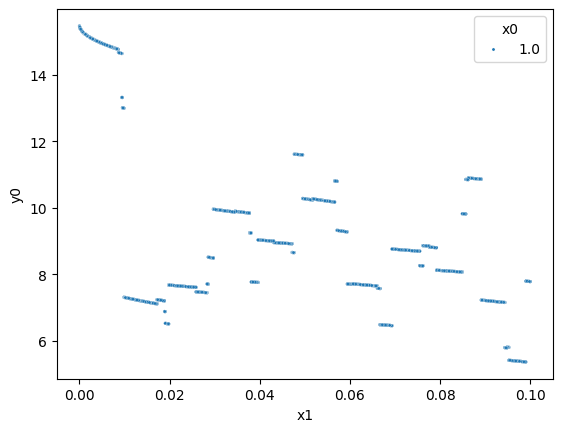

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a data frame from torch arrays dataset.trainX and dataset.trainY
df = pd.DataFrame(
    {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "y2": y2,
        "y3": y3,
    }
)
# Plot y0, y1, y2, y3 as different colored scatter plots with x1 in the x-axis
# Take points where x0 = 1
# use small markers 
sns.scatterplot(df[(df["x0"] >= 1) & (df["x0"] <= 1) & (df["x1"] < 0.1)], x="x1", y="y0",  s=5, hue="x0")
#plt.scatter(x1, y0)
plt.show()



In [98]:
data = [
    {"name": "x0", "value":x0},
    {"name": "x1", "value":x1},
    {"name": "y0", "value":y0, "log":True},
    {"name":  "y1", "value":y1, "log":True},
    {"name": "y2", "value":y2, "log":True},
    {"name":  "y3", "value":y3, "log":True}
]


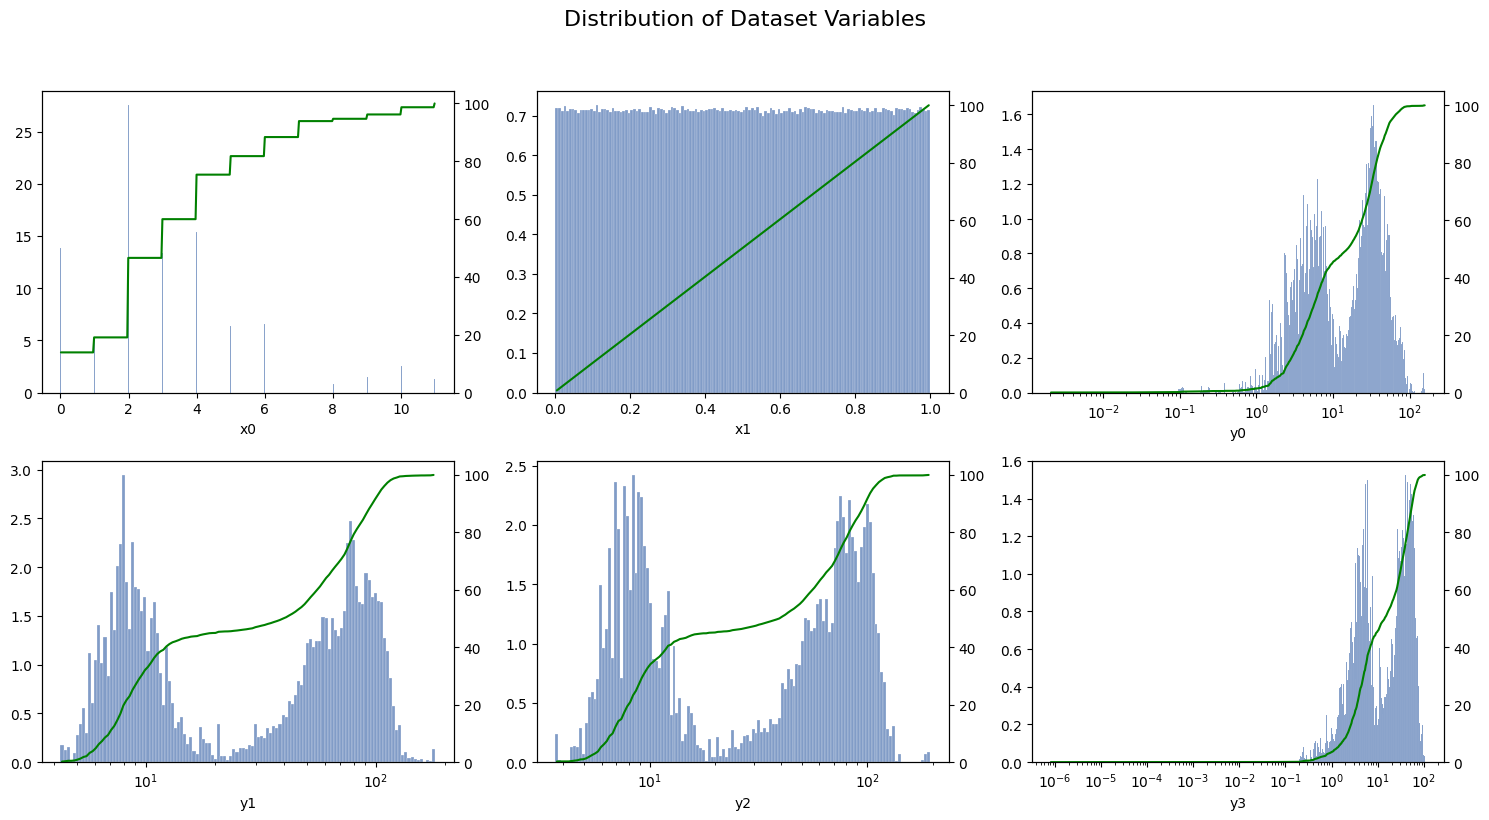

In [99]:
num_variables = len(data)
num_cols = 3
num_rows = math.ceil(num_variables / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
axes_flat = axes.flatten() # Flatten the 2D array of axes for easy iteration

# --- 5. Iterate Through Variables and Plot on Subplots ---
def plot(i, var_name, values, bins="auto", log=False):
    ax = axes_flat[i]

    plot_instance1 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax) # Attach this plot to ax1
        .add(so.Bars(), so.Hist(bins=bins, stat='percent'))
    )

    ax2 = ax.twinx()
    plot_instance2 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax2) # Attach this plot to ax1
        .add(so.Line(color='green'), so.Hist(bins=bins, stat='percent', cumulative=True))
        .limit(y=(0, None))
    )

    if log:
        plot_instance1 = plot_instance1.scale(x='log')
        plot_instance2 = plot_instance2.scale(x='log')

    plot_instance1.plot()
    plot_instance2.plot()

    ax2.yaxis.tick_right()
    ax.set_xlabel(var_name)

for (i, d) in enumerate(data):
    plot(i, d["name"], d["value"], log=d.get("log"), bins=d.get("bins") or "auto")
for j in range(num_variables, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.tight_layout()
fig.suptitle("Distribution of Dataset Variables", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.savefig("distribution.svg")

In [100]:
print(f"Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]")
print("-" * 81)
for d in data:
    v = d["value"]
    print(f"{d["name"]:25} = {np.mean(v):+.5f} (+/- {np.std(v):9.6f}) [{np.min(v):12.6f}, {np.max(v):12.6f}]")

print(f"Total Datapoints: {data[0]['value'].size}")

Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]
---------------------------------------------------------------------------------
x0                        = +3.31532 (+/-  2.514430) [    0.000000,    11.000000]
x1                        = +0.49989 (+/-  0.288768) [    0.000000,     1.000000]
y0                        = +21.52005 (+/- 20.294522) [   -5.178817,   159.698624]
y1                        = +44.63087 (+/- 37.262945) [    4.247668,   180.812790]
y2                        = +44.83979 (+/- 37.729926) [    3.678209,   194.584946]
y3                        = -23.11082 (+/- 22.175858) [ -106.613602,     9.209039]
Total Datapoints: 2720000


In [27]:
# Load the model checkpoint 
from model import create_model
from dataset import load_dataset
from train import Checkpoint
import pyrallis
from config import Config
from pathlib import Path

root = Path(project_root_dir)
checkpoint_path = root.joinpath("logs/macro_xs_tune01/20260210-195301-Lxhv/")
config_path=checkpoint_path.joinpath("./config.yaml")
config = pyrallis.parse(config_class=Config, config_path=config_path, args=())

checkpoint: Checkpoint = torch.load(checkpoint_path.joinpath('checkpoint.pth'))
if not checkpoint:
    print(f"Invalid checkpoint directory {checkpoint_path}")
    exit(1)

config.dataset.db_file = root.joinpath(config.dataset.db_file)

dataset = load_dataset(config.dataset)
model = create_model(config.train, dataset)
model.load_state_dict(state_dict=checkpoint['model_state_dict'])
print(f"Saved best val loss: {checkpoint['best_val_loss']}")
model.eval()



Saved best val loss: 0.018507761113783893


MLP(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=4, bias=True)
  )
)

In [104]:
model.eval()
batch_size = 1024

X_full = dataset.validateX
Y_full = dataset.validateY

# Initialize lists to store results
Y_pred_list = []

# Process in batches
with torch.no_grad():  # Disable gradient computation for inference
    for i in range(0, len(X_full), batch_size):
        X_batch = X_full[i:i + batch_size].to(torch.device('cuda'))
        
        Y_pred_batch = model.forward(X_batch).detach().cpu()
        Y_pred_list.append(Y_pred_batch)

        del X_batch
        torch.cuda.empty_cache()

# Concatenate all batches
Y_pred = torch.cat(Y_pred_list, dim=0)

# Convert to numpy
X = X_full.cpu().numpy()
Y_pred = Y_pred.numpy()
Y = Y_full.cpu().numpy()

X, Y_pred

(array([[0.        , 0.01118364],
        [4.        , 0.84073794],
        [3.        , 0.24782361],
        ...,
        [3.        , 0.79681396],
        [6.        , 0.92911822],
        [4.        , 0.86865628]], shape=(680000, 2)),
 array([[ 84.63167358,  94.89144611,  94.31013265, -10.01980418],
        [ 37.69657793,  74.83584275,  77.99098533, -37.17006741],
        [  3.01069447,   5.84417566,   7.59934741,  -3.11591321],
        ...,
        [  3.50407411,   9.17170869,   9.80350692,  -6.1505621 ],
        [ 28.59859969,  58.88842889,  58.48562661, -30.60744939],
        [ 27.50536029,  79.75388519,  81.42229375, -52.45688966]],
       shape=(680000, 4)))

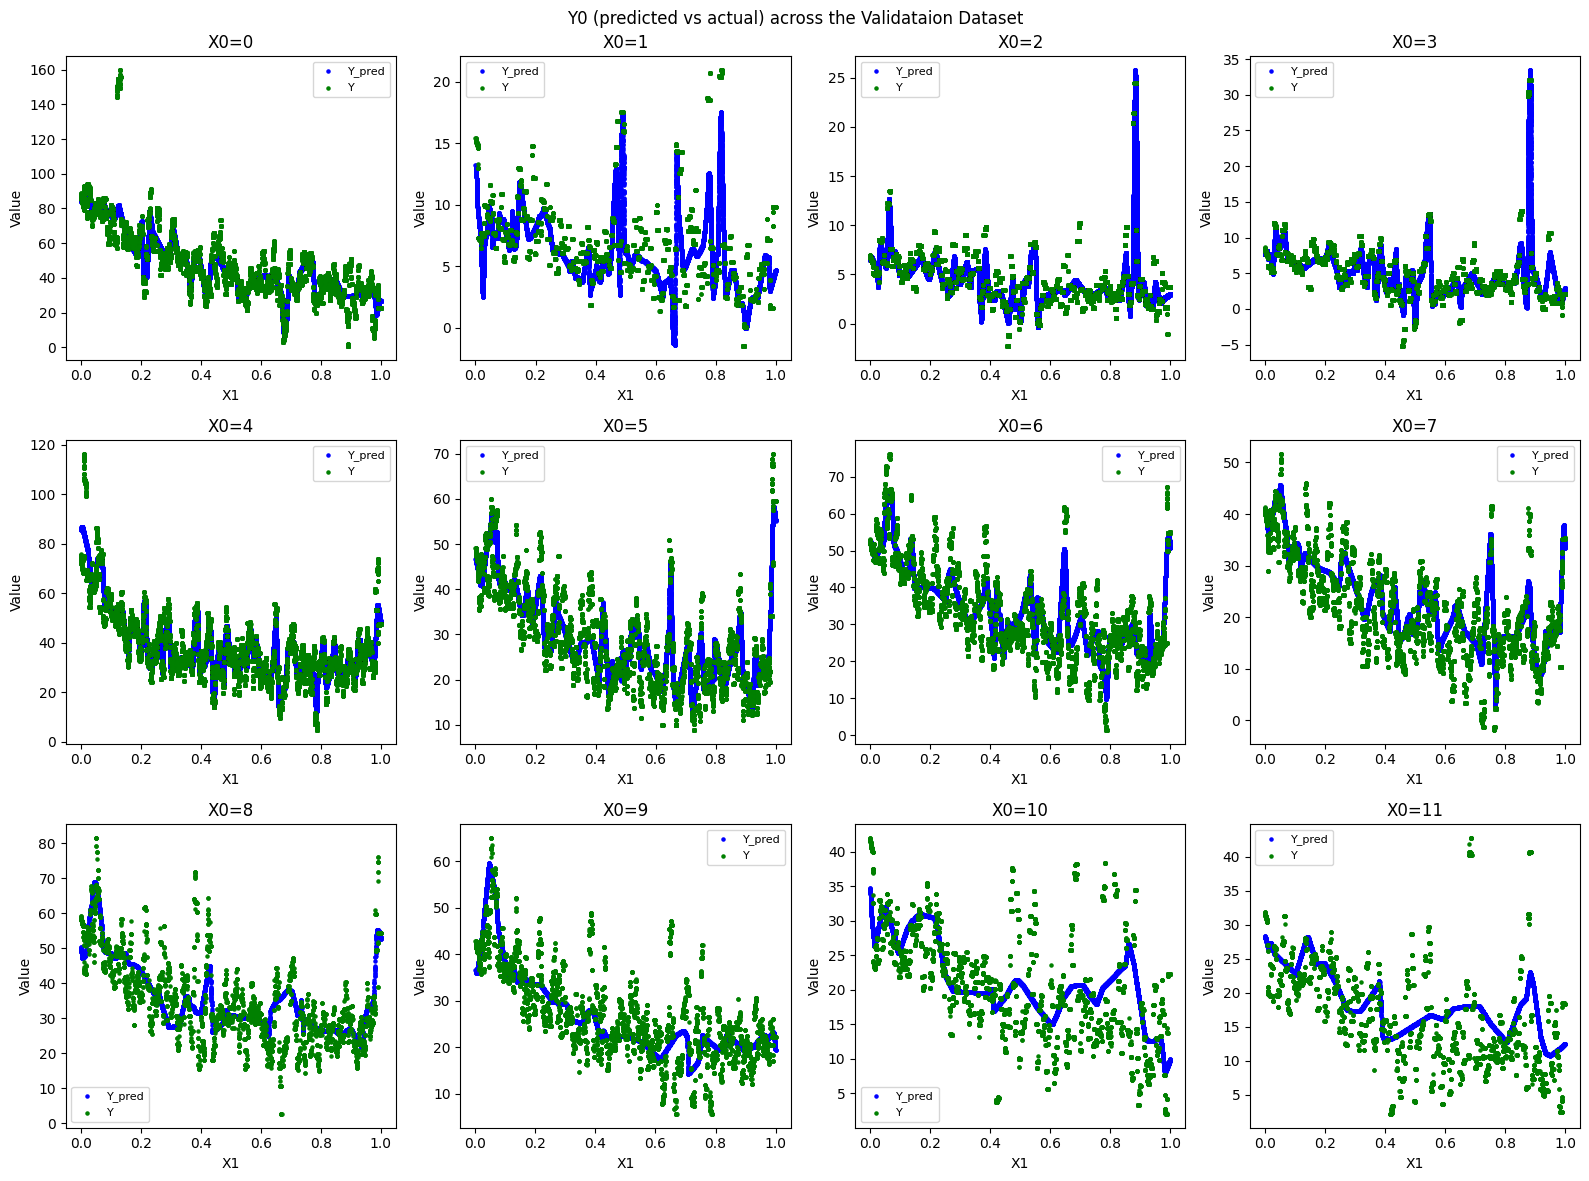

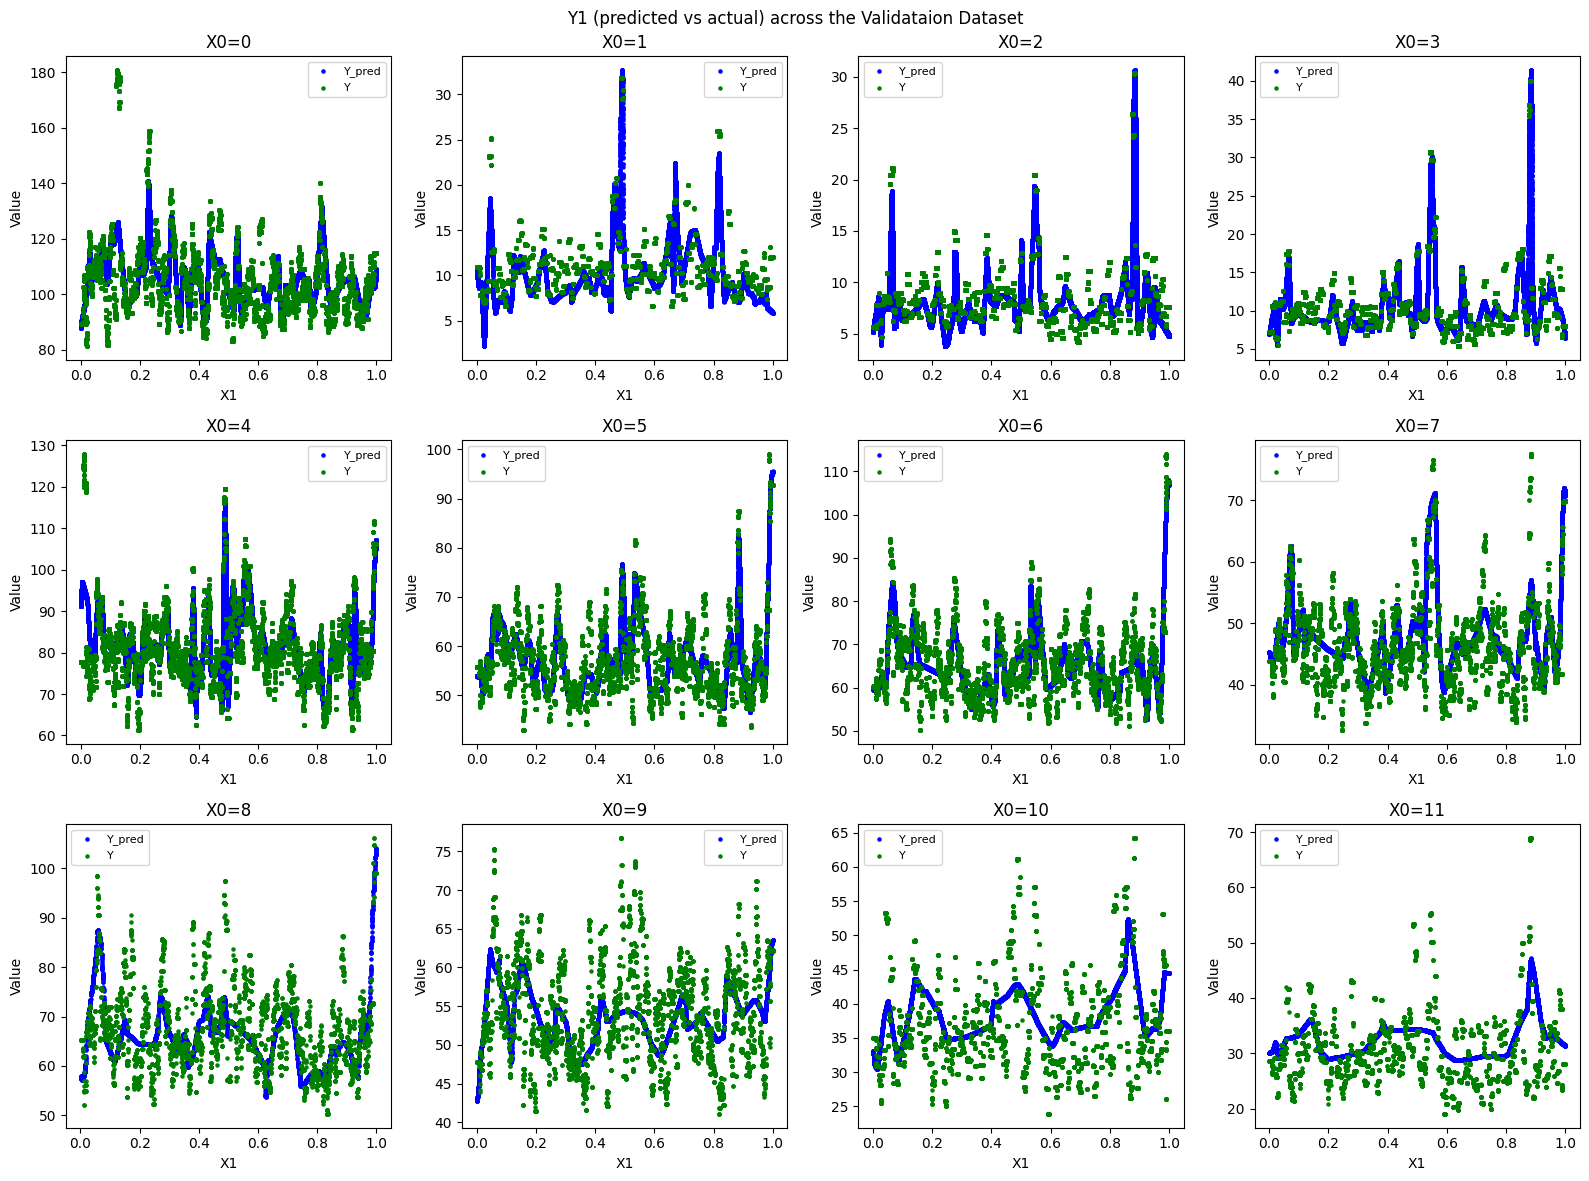

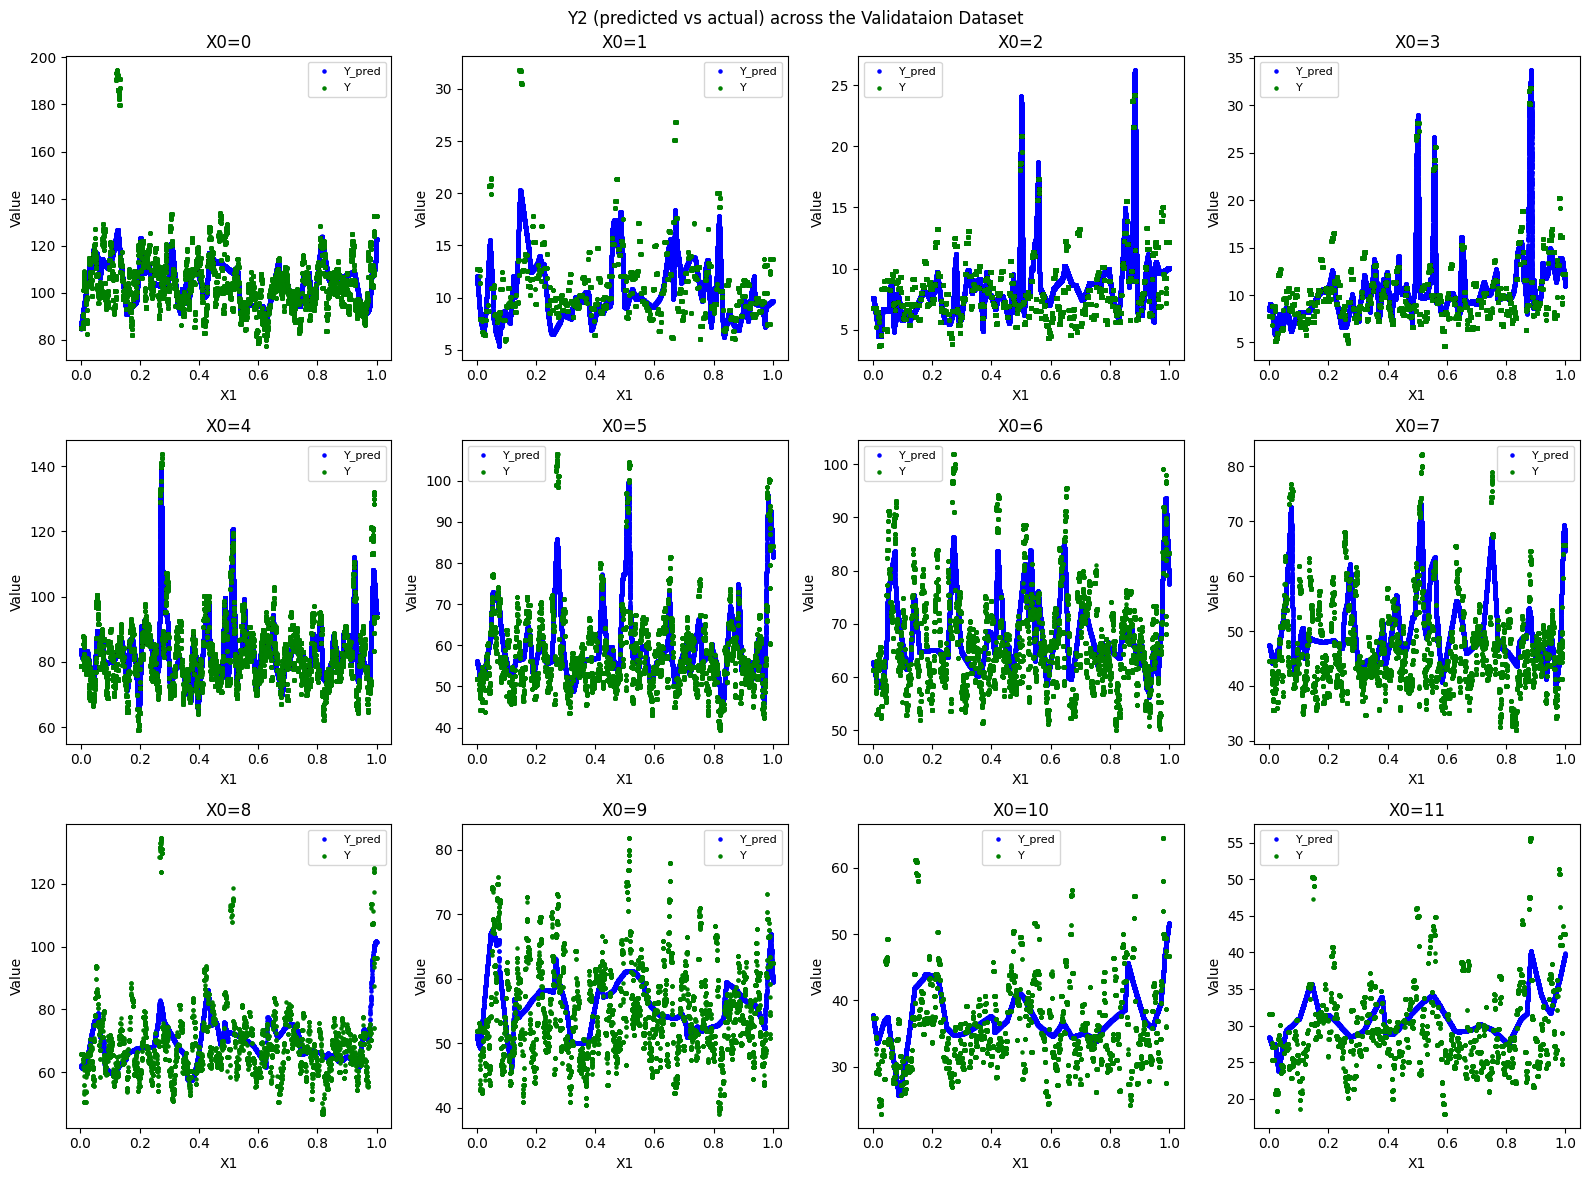

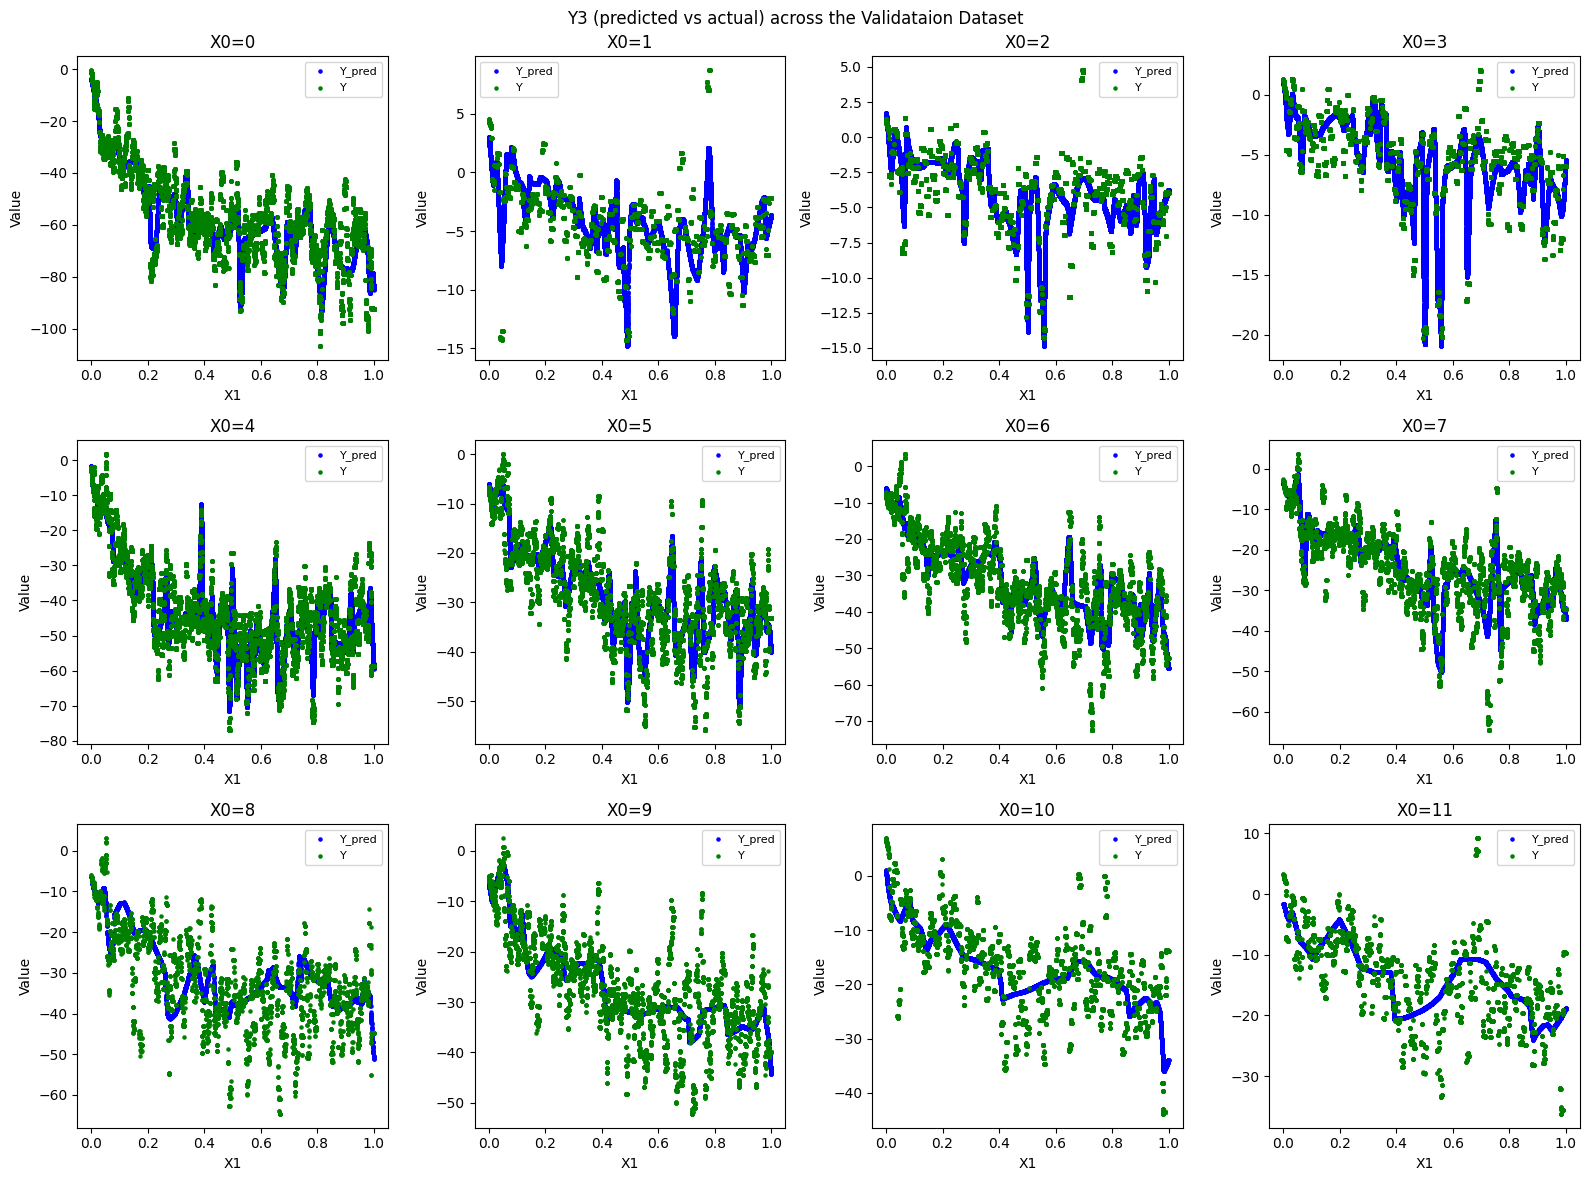

In [105]:
# Create a data frame from torch arrays dataset.trainX and dataset.trainY
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


for yi in range(4):
    xi = 11
    arr = np.column_stack([X[:, 0], X[:,1], Y_pred[:, yi], Y[:, yi]])
    df = pd.DataFrame(arr, columns=["X0", "X1", "Y_pred", "Y"])

    fix, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for xi in range(12):
        ax = axes[xi]
        filtered_df = df[(df["X0"] == xi)]
        ax.scatter(filtered_df["X1"], filtered_df["Y_pred"], s=5, label="Y_pred", color="blue")
        ax.scatter(filtered_df["X1"], filtered_df["Y"], s=5, label="Y", color="green")
        ax.set_xlabel("X1")
        ax.set_ylabel("Value")
        ax.set_title(f"X0={xi}")
        ax.legend(fontsize=8)

    plt.suptitle(f"Y{yi} (predicted vs actual) across the Validataion Dataset")
    plt.tight_layout()
    plt.savefig(checkpoint_path.joinpath(f"figs/val_{yi}.svg"))
    plt.show()

